In [1]:
import torch
import torch.nn as nn

class ElastoplasticMaterial:

    def __init__(self, E=200.0, sigma_y=0.2):
        self.E = E
        self.sigma_y = sigma_y
        self.eps_p = 0.0

    def update(self, eps):

        trial = self.E * (eps - self.eps_p)

        if abs(trial) > self.sigma_y:
            delta_gamma = (abs(trial) - self.sigma_y)/self.E
            self.eps_p += delta_gamma * torch.sign(trial)

        sigma = self.E * (eps - self.eps_p)

        return sigma

In [2]:
class PRNN(nn.Module):

    def __init__(self, n_points=3):
        super().__init__()

        self.encoder = nn.Linear(1, n_points)

        self.weights = nn.Parameter(torch.ones(n_points))

        self.materials = [ElastoplasticMaterial() for _ in range(n_points)]

    def forward(self, eps):

        eps_local = self.encoder(eps)

        sigmas = []

        for j, mat in enumerate(self.materials):
            s = mat.update(eps_local[:, j])
            sigmas.append(s)

        sigmas = torch.stack(sigmas, dim=1)

        sigma_macro = (sigmas * self.weights).sum(dim=1)

        return sigma_macro

In [3]:
model = PRNN()

eps = torch.linspace(0,0.01,100).unsqueeze(1)

sigma = []

for e in eps:
    s = model(e.unsqueeze(0))
    sigma.append(s.item())

In [ ]:

import matplotlib.pyplot as plt

plt.plot(eps, sigma)
plt.xlabel("strain")
plt.ylabel("stress")
plt.show()

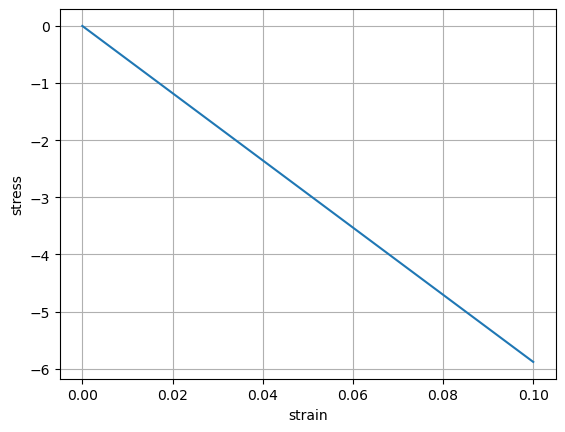

In [2]:
import torch
torch.manual_seed(0)

import torch.nn as nn
import matplotlib.pyplot as plt

class ElastoplasticMaterial:
    def __init__(self, E=200.0, sigma_y=0.2):
        self.E = float(E)
        self.sigma_y = float(sigma_y)
        self.eps_p = 0.0

    def update(self, eps):
        eps_val = float(eps.detach().cpu().item())

        trial = self.E * (eps_val - self.eps_p)

        if abs(trial) > self.sigma_y:
            delta_gamma = (abs(trial) - self.sigma_y) / self.E
            self.eps_p += delta_gamma * (1.0 if trial >= 0.0 else -1.0)

        sigma = self.E * (eps_val)
        return sigma

class PRNN(nn.Module):
    def __init__(self, n_points=3):
        super().__init__()
        self.encoder = nn.Linear(1, n_points, bias=False)
        self.weights = nn.Parameter(torch.ones(n_points))
        self.materials = [ElastoplasticMaterial() for _ in range(n_points)]

    def forward(self, eps):
        eps_local = self.encoder(eps)

        sigmas = []
        for j, mat in enumerate(self.materials):
            s = mat.update(eps_local[:, j])
            sigmas.append(s)

        sigmas = torch.tensor(sigmas, dtype=eps.dtype, device=eps.device).unsqueeze(0)
        sigma_macro = (sigmas * self.weights).sum(dim=1)
        return sigma_macro

model = PRNN()

eps = torch.linspace(0.0, 0.1, 100).unsqueeze(1)
sigma = []

with torch.no_grad():
    
    for e in eps:
        s = model(e.unsqueeze(0))
        sigma.append(float(s.item()))

plt.figure()
plt.plot(eps.numpy(), sigma)
plt.xlabel("strain")
plt.ylabel("stress")
plt.grid(True)
plt.show()

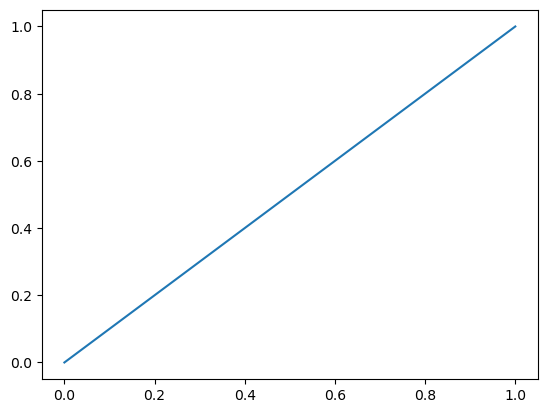

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot([0, 1], [0, 1])
plt.show()

Epoch    0 | Loss = 1.109798e+02
Epoch  100 | Loss = 1.044359e-01
Epoch  200 | Loss = 6.401891e-02
Epoch  300 | Loss = 4.017372e-02
Epoch  400 | Loss = 1.992381e-02
Epoch  500 | Loss = 9.021061e-03
Epoch  600 | Loss = 3.675134e-03
Epoch  700 | Loss = 1.347228e-03
Epoch  800 | Loss = 4.438701e-04
Epoch  900 | Loss = 1.311171e-04


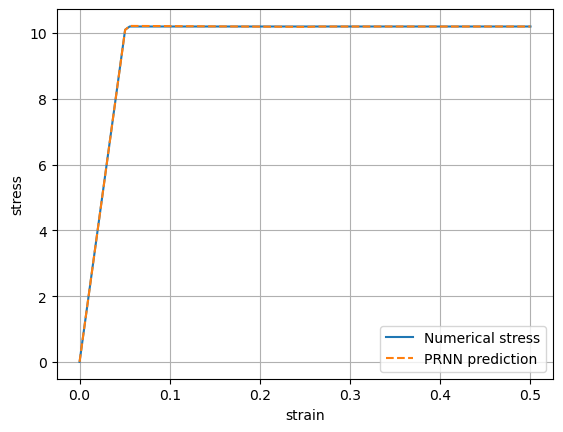

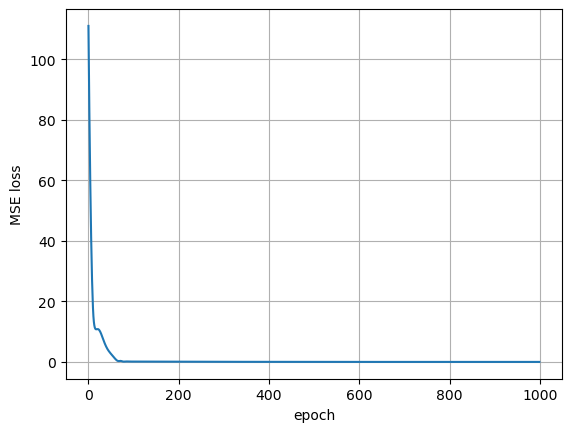

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --------------------------------------------------
# 1. Reference numerical constitutive model
# --------------------------------------------------
def numerical_elastoplastic_response(eps_hist, E=200.0, sigma_y=10.2):
    """
    Compute reference stress history using a simple 1D elastic-perfectly plastic update.
    eps_hist: tensor of shape [N, 1]
    returns: tensor of shape [N, 1]
    """
    eps_p = torch.tensor(0.0)
    sigma_hist = []

    for i in range(len(eps_hist)):
        eps = eps_hist[i, 0]
        trial = E * (eps - eps_p)

        if torch.abs(trial) > sigma_y:
            delta_gamma = (torch.abs(trial) - sigma_y) / E
            eps_p = eps_p + delta_gamma * torch.sign(trial)

        sigma = E * (eps - eps_p)
        sigma_hist.append(sigma)

    return torch.stack(sigma_hist).unsqueeze(1)


# --------------------------------------------------
# 2. Differentiable material point
# --------------------------------------------------
class DifferentiableElastoplasticMaterial(nn.Module):
    def __init__(self, E=200.0, sigma_y=10.2):
        super().__init__()
        self.E = E
        self.sigma_y = sigma_y
        self.reset_state()

    def reset_state(self):
        self.eps_p = torch.tensor(0.0)

    def update(self, eps):
        """
        eps: scalar tensor
        returns: scalar tensor
        """
        trial = self.E * (eps - self.eps_p)

        # differentiable-ish projection using where
        delta_gamma = torch.clamp((torch.abs(trial) - self.sigma_y) / self.E, min=0.0)
        self.eps_p = self.eps_p + delta_gamma * torch.sign(trial)

        sigma = self.E * (eps - self.eps_p)
        return sigma


# --------------------------------------------------
# 3. PRNN model
# --------------------------------------------------
class PRNN(nn.Module):
    def __init__(self, n_points=3):
        super().__init__()
        self.encoder = nn.Linear(1, n_points, bias=False)
        self.weights = nn.Parameter(torch.ones(n_points))
        self.materials = nn.ModuleList(
            [DifferentiableElastoplasticMaterial() for _ in range(n_points)]
        )

    def reset_state(self):
        for mat in self.materials:
            mat.reset_state()

    def forward_history(self, eps_hist):
        """
        eps_hist: [N,1]
        returns: sigma_hist [N,1]
        """
        self.reset_state()
        sigma_out = []

        for i in range(len(eps_hist)):
            eps = eps_hist[i:i+1]             # shape [1,1]
            eps_local = self.encoder(eps)     # shape [1,n_points]

            sigmas = []
            for j, mat in enumerate(self.materials):
                s = mat.update(eps_local[0, j])   # scalar tensor
                sigmas.append(s)

            sigmas = torch.stack(sigmas)          # [n_points]
            sigma_macro = torch.sum(sigmas * self.weights)  # scalar
            sigma_out.append(sigma_macro)

        return torch.stack(sigma_out).unsqueeze(1)


# --------------------------------------------------
# 4. Strain history
# --------------------------------------------------
eps = torch.linspace(0.0, 0.5, 100).unsqueeze(1)

# reference/numerical stress
sigma_num = numerical_elastoplastic_response(eps)

# --------------------------------------------------
# 5. Train PRNN to match numerical stress
# --------------------------------------------------
model = PRNN(n_points=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(1000):
    optimizer.zero_grad()

    sigma_pred = model.forward_history(eps)
    loss = loss_fn(sigma_pred, sigma_num)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6e}")

# --------------------------------------------------
# 6. Evaluate
# --------------------------------------------------
with torch.no_grad():
    sigma_pred = model.forward_history(eps)

# --------------------------------------------------
# 7. Plot stress-strain
# --------------------------------------------------
plt.figure()
plt.plot(eps.numpy(), sigma_num.numpy(), label="Numerical stress")
plt.plot(eps.numpy(), sigma_pred.numpy(), "--", label="PRNN prediction")
plt.xlabel("strain")
plt.ylabel("stress")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 8. Plot loss history
# --------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

Epoch    0 | Loss = 4.347686e+01
Epoch  100 | Loss = 3.096115e+00
Epoch  200 | Loss = 6.848390e-01
Epoch  300 | Loss = 4.067966e-01
Epoch  400 | Loss = 2.850102e-01
Epoch  500 | Loss = 2.110887e-01
Epoch  600 | Loss = 1.624449e-01
Epoch  700 | Loss = 1.288287e-01
Epoch  800 | Loss = 1.046207e-01
Epoch  900 | Loss = 8.661210e-02


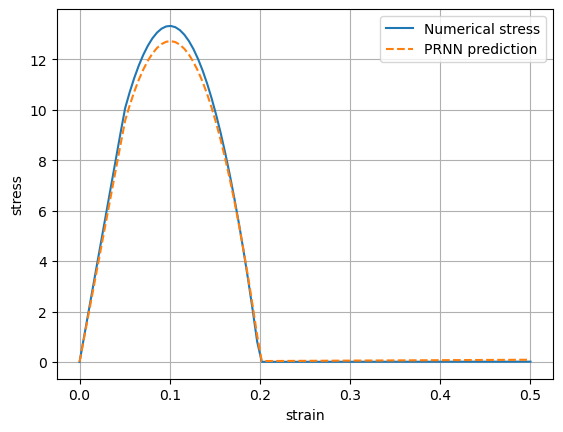

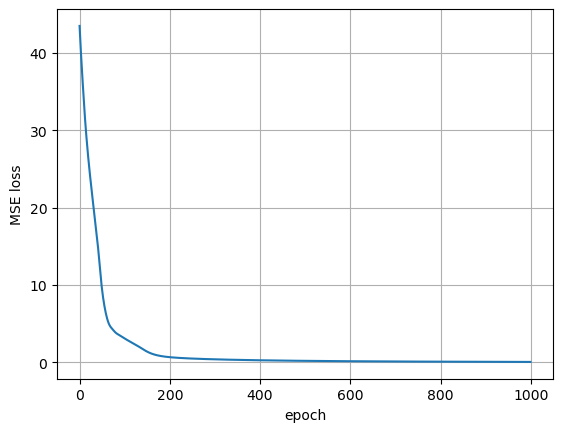

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --------------------------------------------------
# 1. Reference numerical constitutive model (1D CDM, linear softening)
# --------------------------------------------------
def numerical_damage_response(eps_hist, E=200.0, eps0=0.05, epsf=0.20):
    """
    Compute reference stress history using a simple 1D damage model
    with linear softening.
    eps_hist: tensor of shape [N, 1]
    returns: tensor of shape [N, 1]
    """
    kappa = torch.tensor(0.0, dtype=eps_hist.dtype, device=eps_hist.device)
    sigma_hist = []

    for i in range(len(eps_hist)):
        eps = eps_hist[i, 0]
        kappa = torch.maximum(kappa, torch.abs(eps))

        if kappa <= eps0:
            d = torch.tensor(0.0, dtype=eps_hist.dtype, device=eps_hist.device)
        elif kappa >= epsf:
            d = torch.tensor(0.9999, dtype=eps_hist.dtype, device=eps_hist.device)
        else:
            d = (kappa - eps0) / (epsf - eps0)
            d = torch.clamp(d, min=0.0, max=0.9999)

        sigma = (1.0 - d) * E * eps
        sigma_hist.append(sigma)

    return torch.stack(sigma_hist).unsqueeze(1)


# --------------------------------------------------
# 2. Differentiable damage material point
# --------------------------------------------------
class DifferentiableDamageMaterial(nn.Module):
    def __init__(self, E=200.0, eps0=0.05, epsf=0.20):
        super().__init__()
        self.E = E
        self.eps0 = eps0
        self.epsf = epsf
        self.reset_state()

    def reset_state(self):
        self.kappa = None

    def update(self, eps):
        """
        eps: scalar tensor
        returns: scalar tensor
        """
        if self.kappa is None:
            self.kappa = torch.zeros_like(eps)

        self.kappa = torch.maximum(self.kappa, torch.abs(eps))

        d = torch.where(
            self.kappa <= self.eps0,
            torch.zeros_like(eps),
            torch.where(
                self.kappa >= self.epsf,
                0.9999 * torch.ones_like(eps),
                (self.kappa - self.eps0) / (self.epsf - self.eps0)
            )
        )

        d = torch.clamp(d, min=0.0, max=0.9999)

        sigma = (1.0 - d) * self.E * eps
        return sigma


# --------------------------------------------------
# 3. PRNN model
# --------------------------------------------------
class PRNN(nn.Module):
    def __init__(self, n_points=3):
        super().__init__()
        self.encoder = nn.Linear(1, n_points, bias=False)
        self.weights = nn.Parameter(torch.ones(n_points))
        self.materials = nn.ModuleList(
            [DifferentiableDamageMaterial(E=200.0, eps0=0.05, epsf=0.20)
             for _ in range(n_points)]
        )

    def reset_state(self):
        for mat in self.materials:
            mat.reset_state()

    def forward_history(self, eps_hist):
        self.reset_state()
        sigma_out = []

        for i in range(len(eps_hist)):
            eps = eps_hist[i:i+1]         # [1,1]
            eps_local = self.encoder(eps) # [1,n_points]

            sigmas = []
            for j, mat in enumerate(self.materials):
                s = mat.update(eps_local[0, j])
                sigmas.append(s)

            sigmas = torch.stack(sigmas)

            # safer bounded positive weights
            w = torch.softmax(self.weights, dim=0)
            sigma_macro = torch.sum(sigmas * w)

            sigma_out.append(sigma_macro)

        return torch.stack(sigma_out).unsqueeze(1)


# --------------------------------------------------
# 4. Strain history
# --------------------------------------------------
eps = torch.linspace(0.0, 0.5, 100).unsqueeze(1)

# reference/numerical stress
sigma_num = numerical_damage_response(eps, E=200.0, eps0=0.05, epsf=0.20)

# --------------------------------------------------
# 5. Train PRNN to match numerical stress
# --------------------------------------------------
model = PRNN(n_points=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(1000):
    optimizer.zero_grad()

    sigma_pred = model.forward_history(eps)
    loss = loss_fn(sigma_pred, sigma_num)

    if torch.isnan(loss):
        print(f"NaN detected at epoch {epoch}")
        break

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6e}")

# --------------------------------------------------
# 6. Evaluate
# --------------------------------------------------
with torch.no_grad():
    sigma_pred = model.forward_history(eps)

# --------------------------------------------------
# 7. Plot stress-strain
# --------------------------------------------------
plt.figure()
plt.plot(eps.numpy(), sigma_num.numpy(), label="Numerical stress")
plt.plot(eps.numpy(), sigma_pred.numpy(), "--", label="PRNN prediction")
plt.xlabel("strain")
plt.ylabel("stress")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 8. Plot loss history
# --------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

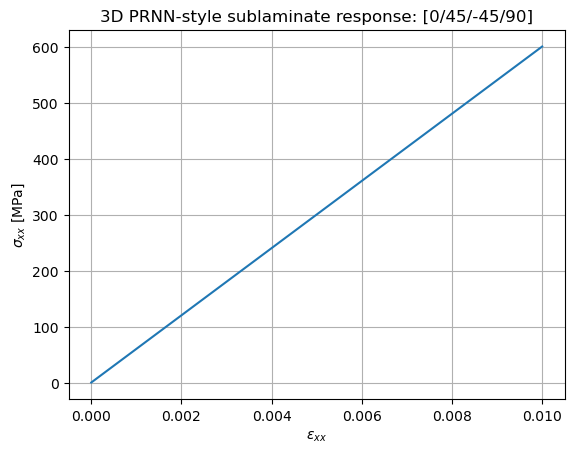

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)


# ============================================================
# Helpers: Voigt <-> tensor conversions (engineering strain)
# ============================================================

def strain_voigt_to_tensor(eps_v):
    """
    Voigt strain [exx, eyy, ezz, gyz, gxz, gxy]
    -> 3x3 small-strain tensor
    Note: engineering shear strains are halved in tensor form.
    """
    e = torch.zeros((3, 3), dtype=eps_v.dtype, device=eps_v.device)
    e[0, 0] = eps_v[0]
    e[1, 1] = eps_v[1]
    e[2, 2] = eps_v[2]
    e[1, 2] = e[2, 1] = 0.5 * eps_v[3]
    e[0, 2] = e[2, 0] = 0.5 * eps_v[4]
    e[0, 1] = e[1, 0] = 0.5 * eps_v[5]
    return e


def strain_tensor_to_voigt(eps_t):
    """
    3x3 small-strain tensor
    -> Voigt strain [exx, eyy, ezz, gyz, gxz, gxy]
    """
    return torch.stack([
        eps_t[0, 0],
        eps_t[1, 1],
        eps_t[2, 2],
        2.0 * eps_t[1, 2],
        2.0 * eps_t[0, 2],
        2.0 * eps_t[0, 1],
    ])


def stress_voigt_to_tensor(sig_v):
    """
    Voigt stress [sxx, syy, szz, tyz, txz, txy]
    -> 3x3 Cauchy stress tensor
    """
    s = torch.zeros((3, 3), dtype=sig_v.dtype, device=sig_v.device)
    s[0, 0] = sig_v[0]
    s[1, 1] = sig_v[1]
    s[2, 2] = sig_v[2]
    s[1, 2] = s[2, 1] = sig_v[3]
    s[0, 2] = s[2, 0] = sig_v[4]
    s[0, 1] = s[1, 0] = sig_v[5]
    return s


def stress_tensor_to_voigt(sig_t):
    """
    3x3 Cauchy stress tensor
    -> Voigt stress [sxx, syy, szz, tyz, txz, txy]
    """
    return torch.stack([
        sig_t[0, 0],
        sig_t[1, 1],
        sig_t[2, 2],
        sig_t[1, 2],
        sig_t[0, 2],
        sig_t[0, 1],
    ])


# ============================================================
# Rotation
# ============================================================

def rotation_matrix_z(theta_deg, dtype=torch.float32, device="cpu"):
    """
    Rotation about laminate normal z-axis.
    """
    th = torch.tensor(theta_deg * torch.pi / 180.0, dtype=dtype, device=device)
    c = torch.cos(th)
    s = torch.sin(th)

    R = torch.stack([
        torch.stack([ c, s, torch.tensor(0.0, dtype=dtype, device=device)]),
        torch.stack([-s, c, torch.tensor(0.0, dtype=dtype, device=device)]),
        torch.stack([torch.tensor(0.0, dtype=dtype, device=device),
                     torch.tensor(0.0, dtype=dtype, device=device),
                     torch.tensor(1.0, dtype=dtype, device=device)])
    ])
    return R


def transform_strain_global_to_local(eps_global_v, theta_deg):
    """
    Global strain in laminate axes -> local ply material axes
    """
    R = rotation_matrix_z(theta_deg, dtype=eps_global_v.dtype, device=eps_global_v.device)
    eps_g = strain_voigt_to_tensor(eps_global_v)
    eps_l = R @ eps_g @ R.T
    return strain_tensor_to_voigt(eps_l)


def transform_stress_local_to_global(sig_local_v, theta_deg):
    """
    Local ply stress -> global laminate axes
    """
    R = rotation_matrix_z(theta_deg, dtype=sig_local_v.dtype, device=sig_local_v.device)
    sig_l = stress_voigt_to_tensor(sig_local_v)
    sig_g = R.T @ sig_l @ R
    return stress_tensor_to_voigt(sig_g)


# ============================================================
# 3D orthotropic elasticity matrix
# ============================================================

def orthotropic_stiffness_3d(E1, E2, E3, nu12, nu13, nu23, G12, G13, G23,
                             dtype=torch.float32, device="cpu"):
    """
    Build 3D orthotropic stiffness matrix C (6x6) from engineering constants.
    Uses compliance inversion.
    """
    nu21 = nu12 * E2 / E1
    nu31 = nu13 * E3 / E1
    nu32 = nu23 * E3 / E2

    S = torch.zeros((6, 6), dtype=dtype, device=device)

    S[0, 0] = 1.0 / E1
    S[1, 1] = 1.0 / E2
    S[2, 2] = 1.0 / E3

    S[0, 1] = -nu21 / E2
    S[1, 0] = -nu12 / E1

    S[0, 2] = -nu31 / E3
    S[2, 0] = -nu13 / E1

    S[1, 2] = -nu32 / E3
    S[2, 1] = -nu23 / E2

    S[3, 3] = 1.0 / G23
    S[4, 4] = 1.0 / G13
    S[5, 5] = 1.0 / G12

    C = torch.linalg.inv(S)
    return C


# ============================================================
# Ply material point
# ============================================================

class OrthotropicPly3D(nn.Module):
    """
    Simple 3D orthotropic ply material point.
    No damage yet. This is the base PRNN material block.
    """
    def __init__(self, C_local):
        super().__init__()
        self.register_buffer("C_local", C_local)

    def update(self, eps_local_v):
        """
        eps_local_v: [6]
        sigma_local_v: [6]
        """
        sigma_local_v = self.C_local @ eps_local_v
        return sigma_local_v


# ============================================================
# Sublaminate PRNN
# ============================================================

class SublaminatePRNN(nn.Module):
    """
    PRNN-style sublaminate model with 4 plies:
      [0 / 45 / -45 / 90]

    Structure:
      global strain -> ply-axis transform -> ply constitutive response
      -> back-transform stress -> homogenise
    """
    def __init__(self, ply_angles, ply_thickness_fractions, C_local):
        super().__init__()

        assert len(ply_angles) == len(ply_thickness_fractions)

        self.ply_angles = ply_angles
        self.register_buffer(
            "ply_fractions",
            torch.tensor(ply_thickness_fractions, dtype=torch.float32)
        )

        self.plies = nn.ModuleList([
            OrthotropicPly3D(C_local) for _ in ply_angles
        ])

    def forward_history(self, eps_hist):
        """
        eps_hist: [N, 6]
        returns sigma_hist: [N, 6]
        """
        sigma_hist = []

        for n in range(eps_hist.shape[0]):
            eps_g = eps_hist[n]                       # [6]
            sigma_g_total = torch.zeros_like(eps_g)  # [6]

            for k, theta in enumerate(self.ply_angles):
                # 1. transform strain to ply material axis
                eps_l = transform_strain_global_to_local(eps_g, theta)

                # 2. ply constitutive response
                sigma_l = self.plies[k].update(eps_l)

                # 3. transform ply stress back to global axis
                sigma_g = transform_stress_local_to_global(sigma_l, theta)

                # 4. homogenise
                sigma_g_total = sigma_g_total + self.ply_fractions[k] * sigma_g

            sigma_hist.append(sigma_g_total)

        return torch.stack(sigma_hist, dim=0)


# ============================================================
# Example: [0 / 45 / -45 / 90] sublaminate
# ============================================================

# Example UD ply properties
E1  = 135e9
E2  = 10e9
E3  = 10e9
nu12 = 0.30
nu13 = 0.30
nu23 = 0.40
G12 = 5e9
G13 = 5e9
G23 = 3.8e9

C_local = orthotropic_stiffness_3d(
    E1, E2, E3, nu12, nu13, nu23, G12, G13, G23
)

angles = [0.0, 45.0, -45.0, 90.0]
fractions = [0.25, 0.25, 0.25, 0.25]

model = SublaminatePRNN(
    ply_angles=angles,
    ply_thickness_fractions=fractions,
    C_local=C_local
)

# ============================================================
# Example loading history
# ============================================================

N = 200
eps_hist = torch.zeros((N, 6), dtype=torch.float32)

# Apply global exx loading
eps_hist[:, 0] = torch.linspace(0.0, 0.01, N)

# You can also add shear, ezz, etc.
# eps_hist[:, 5] = torch.linspace(0.0, 0.005, N)   # gamma_xy

sigma_hist = model.forward_history(eps_hist)

# ============================================================
# Plot sigma_xx vs epsilon_xx
# ============================================================

plt.figure()
plt.plot(eps_hist[:, 0].numpy(), sigma_hist[:, 0].numpy() / 1e6)
plt.xlabel(r'$\varepsilon_{xx}$')
plt.ylabel(r'$\sigma_{xx}$ [MPa]')
plt.title('3D PRNN-style sublaminate response: [0/45/-45/90]')
plt.grid(True)
plt.show()

<>:291: SyntaxWarning: invalid escape sequence '\s'
<>:292: SyntaxWarning: invalid escape sequence '\s'
<>:291: SyntaxWarning: invalid escape sequence '\s'
<>:292: SyntaxWarning: invalid escape sequence '\s'
C:\Users\js666j\AppData\Local\Temp\ipykernel_68320\2371387045.py:291: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(eps_hist[:, 0].numpy(), sigma_num[:, 0].numpy()/1e6, label="Numerical $\sigma_{xx}$")
C:\Users\js666j\AppData\Local\Temp\ipykernel_68320\2371387045.py:292: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(eps_hist[:, 0].numpy(), sigma_pred[:, 0].numpy()/1e6, "--", label="PRNN $\sigma_{xx}$")


Epoch    0 | Loss = 5.181157e+15
Epoch  100 | Loss = 2.983151e+10
Epoch  200 | Loss = 2.294424e+06
Epoch  300 | Loss = 2.713708e+02
Epoch  400 | Loss = 1.916875e+02
Epoch  500 | Loss = 1.930875e+02
Epoch  600 | Loss = 1.918875e+02
Epoch  700 | Loss = 1.874875e+02
Epoch  800 | Loss = 1.874875e+02
Epoch  900 | Loss = 1.862875e+02


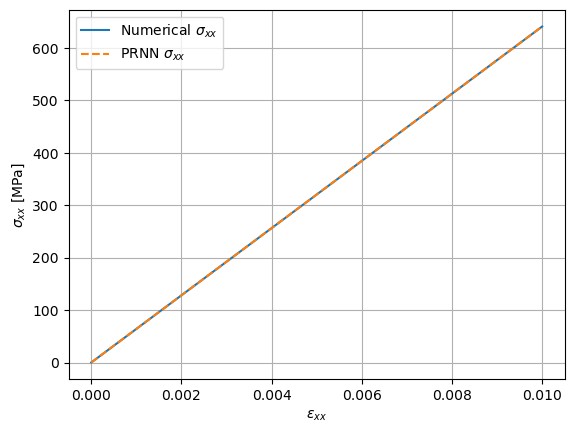

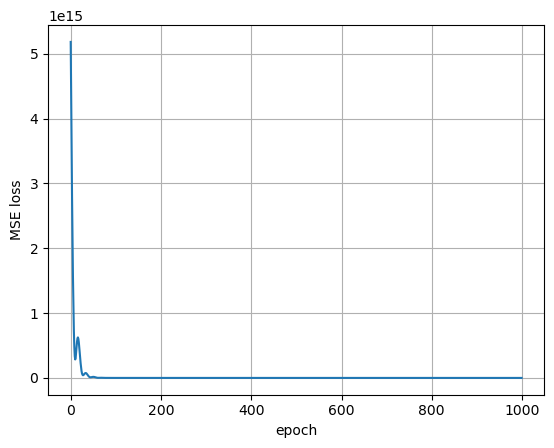

Learned ply weights = tensor([0.3386, 0.3322, 0.1864, 0.1428])


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# ============================================================
# Helpers: Voigt <-> tensor conversions
# ============================================================

def strain_voigt_to_tensor(eps_v):
    e = torch.zeros((3, 3), dtype=eps_v.dtype, device=eps_v.device)
    e[0, 0] = eps_v[0]
    e[1, 1] = eps_v[1]
    e[2, 2] = eps_v[2]
    e[1, 2] = e[2, 1] = 0.5 * eps_v[3]
    e[0, 2] = e[2, 0] = 0.5 * eps_v[4]
    e[0, 1] = e[1, 0] = 0.5 * eps_v[5]
    return e

def strain_tensor_to_voigt(eps_t):
    return torch.stack([
        eps_t[0, 0],
        eps_t[1, 1],
        eps_t[2, 2],
        2.0 * eps_t[1, 2],
        2.0 * eps_t[0, 2],
        2.0 * eps_t[0, 1],
    ])

def stress_voigt_to_tensor(sig_v):
    s = torch.zeros((3, 3), dtype=sig_v.dtype, device=sig_v.device)
    s[0, 0] = sig_v[0]
    s[1, 1] = sig_v[1]
    s[2, 2] = sig_v[2]
    s[1, 2] = s[2, 1] = sig_v[3]
    s[0, 2] = s[2, 0] = sig_v[4]
    s[0, 1] = s[1, 0] = sig_v[5]
    return s

def stress_tensor_to_voigt(sig_t):
    return torch.stack([
        sig_t[0, 0],
        sig_t[1, 1],
        sig_t[2, 2],
        sig_t[1, 2],
        sig_t[0, 2],
        sig_t[0, 1],
    ])

# ============================================================
# Rotation about laminate z-axis
# ============================================================

def rotation_matrix_z(theta_deg, dtype=torch.float32, device="cpu"):
    th = torch.tensor(theta_deg * torch.pi / 180.0, dtype=dtype, device=device)
    c = torch.cos(th)
    s = torch.sin(th)
    z = torch.tensor(0.0, dtype=dtype, device=device)
    o = torch.tensor(1.0, dtype=dtype, device=device)

    R = torch.stack([
        torch.stack([c,  s, z]),
        torch.stack([-s, c, z]),
        torch.stack([z,  z, o])
    ])
    return R

def transform_strain_global_to_local(eps_global_v, theta_deg):
    R = rotation_matrix_z(theta_deg, dtype=eps_global_v.dtype, device=eps_global_v.device)
    eps_g = strain_voigt_to_tensor(eps_global_v)
    eps_l = R @ eps_g @ R.T
    return strain_tensor_to_voigt(eps_l)

def transform_stress_local_to_global(sig_local_v, theta_deg):
    R = rotation_matrix_z(theta_deg, dtype=sig_local_v.dtype, device=sig_local_v.device)
    sig_l = stress_voigt_to_tensor(sig_local_v)
    sig_g = R.T @ sig_l @ R
    return stress_tensor_to_voigt(sig_g)

# ============================================================
# 3D orthotropic stiffness
# ============================================================

def orthotropic_stiffness_3d(E1, E2, E3, nu12, nu13, nu23, G12, G13, G23,
                             dtype=torch.float32, device="cpu"):
    nu21 = nu12 * E2 / E1
    nu31 = nu13 * E3 / E1
    nu32 = nu23 * E3 / E2

    S = torch.zeros((6, 6), dtype=dtype, device=device)

    S[0, 0] = 1.0 / E1
    S[1, 1] = 1.0 / E2
    S[2, 2] = 1.0 / E3

    S[0, 1] = -nu21 / E2
    S[1, 0] = -nu12 / E1

    S[0, 2] = -nu31 / E3
    S[2, 0] = -nu13 / E1

    S[1, 2] = -nu32 / E3
    S[2, 1] = -nu23 / E2

    S[3, 3] = 1.0 / G23
    S[4, 4] = 1.0 / G13
    S[5, 5] = 1.0 / G12

    return torch.linalg.inv(S)

# ============================================================
# Trainable ply block
# ============================================================

class TrainableOrthotropicPly3D(nn.Module):
    """
    Physics-based ply block with trainable stiffness scalings.
    """
    def __init__(self, C_local):
        super().__init__()
        self.register_buffer("C_ref", C_local)

        # trainable positive scale factors for the 6x6 stiffness entries
        # start from 1.0 and constrain positivity with softplus
        self.raw_scale = nn.Parameter(torch.zeros(6))

    def current_C(self):
        scale = torch.nn.functional.softplus(self.raw_scale) + 1e-6
        # map 6 trainable factors to main stiffness groups
        s11, s22, s33, s44, s55, s66 = scale

        C = self.C_ref.clone()
        C[0, 0] = s11 * self.C_ref[0, 0]
        C[1, 1] = s22 * self.C_ref[1, 1]
        C[2, 2] = s33 * self.C_ref[2, 2]
        C[3, 3] = s44 * self.C_ref[3, 3]
        C[4, 4] = s55 * self.C_ref[4, 4]
        C[5, 5] = s66 * self.C_ref[5, 5]

        # optional: scale coupling terms mildly
        C[0, 1] = torch.sqrt(s11 * s22) * self.C_ref[0, 1]
        C[1, 0] = C[0, 1]

        C[0, 2] = torch.sqrt(s11 * s33) * self.C_ref[0, 2]
        C[2, 0] = C[0, 2]

        C[1, 2] = torch.sqrt(s22 * s33) * self.C_ref[1, 2]
        C[2, 1] = C[1, 2]

        return C

    def update(self, eps_local_v):
        C = self.current_C()
        return C @ eps_local_v

# ============================================================
# PRNN-style sublaminate model
# ============================================================

class SublaminatePRNN(nn.Module):
    def __init__(self, ply_angles, ply_thickness_fractions, C_local):
        super().__init__()
        self.ply_angles = ply_angles

        # make thickness weights trainable if desired
        self.raw_weights = nn.Parameter(torch.log(torch.tensor(ply_thickness_fractions, dtype=torch.float32)))

        self.plies = nn.ModuleList([
            TrainableOrthotropicPly3D(C_local) for _ in ply_angles
        ])

    def ply_weights(self):
        return torch.softmax(self.raw_weights, dim=0)

    def forward_history(self, eps_hist):
        sigma_hist = []

        for n in range(eps_hist.shape[0]):
            eps_g = eps_hist[n]
            sigma_g_total = torch.zeros_like(eps_g)

            w = self.ply_weights()

            for k, theta in enumerate(self.ply_angles):
                eps_l = transform_strain_global_to_local(eps_g, theta)
                sigma_l = self.plies[k].update(eps_l)
                sigma_g = transform_stress_local_to_global(sigma_l, theta)
                sigma_g_total = sigma_g_total + w[k] * sigma_g

            sigma_hist.append(sigma_g_total)

        return torch.stack(sigma_hist, dim=0)

# ============================================================
# Synthetic numerical data
# ============================================================

# True ply properties used to generate "numerical" data
E1  = 135e9
E2  = 10e9
E3  = 10e9
nu12 = 0.30
nu13 = 0.30
nu23 = 0.40
G12 = 5e9
G13 = 5e9
G23 = 3.8e9

C_true = orthotropic_stiffness_3d(E1, E2, E3, nu12, nu13, nu23, G12, G13, G23)

angles = [0.0, 45.0, -45.0, 90.0]
fractions = [0.25, 0.25, 0.25, 0.25]

# Create a "true" model to generate numerical stresses
true_model = SublaminatePRNN(angles, fractions, C_true)
with torch.no_grad():
    # force the true model scales near 1
    for ply in true_model.plies:
        ply.raw_scale[:] = torch.log(torch.exp(torch.ones(6)) - 1.0)
    true_model.raw_weights[:] = torch.log(torch.tensor(fractions))

# Strain history: combined normal + shear loading
N = 10
eps_hist = torch.zeros((N, 6), dtype=torch.float32)
eps_hist[:, 0] = torch.linspace(0.0, 0.010, N)   # exx
eps_hist[:, 1] = torch.linspace(0.0, 0.002, N)   # eyy
eps_hist[:, 5] = torch.linspace(0.0, 0.004, N)   # gxy

with torch.no_grad():
    sigma_num = true_model.forward_history(eps_hist)

# Optional noise
noise_level = 0.00
sigma_num = sigma_num + noise_level * torch.std(sigma_num) * torch.randn_like(sigma_num)

# ============================================================
# Initial guess model to train
# ============================================================

# start from a deliberately imperfect reference stiffness
C_guess = orthotropic_stiffness_3d(
    110e9, 12e9, 11e9, 0.28, 0.28, 0.35, 4.0e9, 4.5e9, 3.0e9
)

model = SublaminatePRNN(angles, fractions, C_guess)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-2)
loss_fn = nn.MSELoss()

loss_history = []

# ============================================================
# Training
# ============================================================

for epoch in range(1000):
    optimizer.zero_grad()

    sigma_pred = model.forward_history(eps_hist)

    # main data loss
    loss_data = loss_fn(sigma_pred, sigma_num)

    # small regularization to keep scales reasonable
    reg = 0.0
    for ply in model.plies:
        reg = reg + 1e-6 * torch.sum(ply.raw_scale**2)

    loss = loss_data + reg
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6e}")

# ============================================================
# Evaluation
# ============================================================

with torch.no_grad():
    sigma_pred = model.forward_history(eps_hist)

# ============================================================
# Plots
# ============================================================

plt.figure()
plt.plot(eps_hist[:, 0].numpy(), sigma_num[:, 0].numpy()/1e6, label="Numerical $\sigma_{xx}$")
plt.plot(eps_hist[:, 0].numpy(), sigma_pred[:, 0].numpy()/1e6, "--", label="PRNN $\sigma_{xx}$")
plt.xlabel(r'$\varepsilon_{xx}$')
plt.ylabel(r'$\sigma_{xx}$ [MPa]')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

with torch.no_grad():
    print("Learned ply weights =", model.ply_weights())